# Taylor-Green Vortex Validation

This notebook summarizes a fresh 2D Taylor-Green vortex validation run from `Examples/Taylor_Green_Vortex`. It loads the AMReX plotfiles in `out_validation`, compares the numerical velocity field to the analytical solution, and visualizes how the error evolves over time.


## Compile and run

The short validation rerun used for this notebook was built and run with:

```bash
cd /home/haotian/lattice_boltzmann_method/Examples/Taylor_Green_Vortex
make -j28 USE_MPI=FALSE USE_OMP=TRUE DEBUG=FALSE
OMP_NUM_THREADS=28 ./main2d.gnu.OMP.ex inputs max_step=100 stop_time=100 amr.plot_file=out_validation/plt
```

If you want the longer default run from `inputs`, keep the same executable and drop the `max_step` / `stop_time` overrides:

```bash
OMP_NUM_THREADS=28 ./main2d.gnu.OMP.ex inputs
```


## Exact solution used for validation

For this case the initial condition in `Prob.H` is the decaying 2D Taylor-Green vortex on a periodic box. The exact velocity is

$$u_x(x,y,t) = -U_0 \cos(k_x x) \sin(k_y y) e^{-\nu (k_x^2 + k_y^2)t},$$
$$u_y(x,y,t) = \phantom{-}U_0 \sin(k_x x) \cos(k_y y) e^{-\nu (k_x^2 + k_y^2)t},$$

with `U0 = 0.02`, `nu = 1/6`, and `k_x = 2\pi/L_x`, `k_y = 2\pi/L_y`. The validation metric below is the relative composite-grid velocity `L2` error.


In [1]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
import yt
from IPython.display import Markdown, display

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['image.origin'] = 'lower'
plt.rcParams['image.cmap'] = 'RdBu_r'

CASE_DIR = Path('.')
PLOT_ROOT = CASE_DIR / 'out_validation'
NU = 1.0 / 6.0
U0 = 0.02


/home/haotian/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
def load_composite_fields(plotfile):
    ds = yt.load(str(plotfile))
    ds.force_periodicity()

    level = ds.index.max_level
    ref = 2 ** level
    dims = np.array(ds.domain_dimensions, dtype=int) * ref
    cg = ds.smoothed_covering_grid(level=level, left_edge=ds.domain_left_edge, dims=dims)

    ux = np.array(cg[('boxlib', 'ux')])[:, :, 0]
    uy = np.array(cg[('boxlib', 'uy')])[:, :, 0]
    vor = np.array(cg[('boxlib', 'vor')])[:, :, 0]

    xlo, ylo = ds.domain_left_edge.d[:2]
    xhi, yhi = ds.domain_right_edge.d[:2]
    nx, ny = ux.shape
    dx = (xhi - xlo) / nx
    dy = (yhi - ylo) / ny
    x = xlo + (np.arange(nx) + 0.5) * dx
    y = ylo + (np.arange(ny) + 0.5) * dy
    X, Y = np.meshgrid(x, y, indexing='ij')

    return {
        'ds': ds,
        'level': level,
        'time': float(ds.current_time),
        'x': x,
        'y': y,
        'X': X,
        'Y': Y,
        'ux': ux,
        'uy': uy,
        'vor': vor,
    }

def exact_velocity(X, Y, t, x, y, nu=NU, u0=U0):
    kx = 2.0 * math.pi / (x[-1] - x[0] + (x[1] - x[0]))
    ky = 2.0 * math.pi / (y[-1] - y[0] + (y[1] - y[0]))
    decay = math.exp(-nu * (kx * kx + ky * ky) * t)
    uex = -u0 * np.cos(kx * X) * np.sin(ky * Y) * decay
    vex =  u0 * np.sin(kx * X) * np.cos(ky * Y) * decay
    return uex, vex

def relative_velocity_l2(record):
    uex, vex = exact_velocity(record['X'], record['Y'], record['time'], record['x'], record['y'])
    num = np.sum((record['ux'] - uex) ** 2 + (record['uy'] - vex) ** 2)
    den = np.sum(uex ** 2 + vex ** 2)
    return math.sqrt(num / den), uex, vex

plotfiles = sorted(PLOT_ROOT.glob('plt*'))
if not plotfiles:
    raise FileNotFoundError(f'No plotfiles found in {PLOT_ROOT}')

records = []
for plotfile in plotfiles:
    record = load_composite_fields(plotfile)
    rel_l2, uex, vex = relative_velocity_l2(record)
    record['rel_l2'] = rel_l2
    record['uex'] = uex
    record['vex'] = vex
    record['plotfile'] = plotfile.name
    records.append(record)

snapshot_indices = sorted(set([0, len(records) // 2, len(records) - 1]))
snapshots = [records[i] for i in snapshot_indices]
vor_vmax = max(float(np.max(np.abs(r['vor']))) for r in records)


yt : [INFO     ] 2026-03-28 21:16:22,334 Parameters: current_time              = 0.0


yt : [INFO     ] 2026-03-28 21:16:22,335 Parameters: domain_dimensions         = [64 64  1]


yt : [INFO     ] 2026-03-28 21:16:22,336 Parameters: domain_left_edge          = [0. 0. 0.]


yt : [INFO     ] 2026-03-28 21:16:22,337 Parameters: domain_right_edge         = [64. 64.  1.]


yt : [INFO     ] 2026-03-28 21:16:22,525 Parameters: current_time              = 5.0


...

yt : [INFO     ] 2026-03-28 21:16:25,616 Parameters: domain_right_edge         = [64. 64.  1.]


yt : [INFO     ] 2026-03-28 21:16:25,773 Parameters: current_time              = 100.0


yt : [INFO     ] 2026-03-28 21:16:25,774 Parameters: domain_dimensions         = [64 64  1]


yt : [INFO     ] 2026-03-28 21:16:25,775 Parameters: domain_left_edge          = [0. 0. 0.]


yt : [INFO     ] 2026-03-28 21:16:25,776 Parameters: domain_right_edge         = [64. 64.  1.]


In [3]:
table = ['| Plotfile | Time | Finest level | Relative velocity L2 error |', '|---|---:|---:|---:|']
for r in records:
    table.append(f"| {r['plotfile']} | {r['time']:.1f} | {r['level']} | {r['rel_l2']:.6e} |")
display(Markdown('\n'.join(table)))


| Plotfile | Time | Finest level | Relative velocity L2 error |
|---|---:|---:|---:|
| plt00000 | 0.0 | 2 | 2.088613e-03 |
| plt00005 | 5.0 | 2 | 2.907678e-03 |
| plt00010 | 10.0 | 2 | 3.808982e-03 |
| plt00015 | 15.0 | 2 | 4.582236e-03 |
| plt00020 | 20.0 | 2 | 5.518835e-03 |
| plt00025 | 25.0 | 2 | 6.522131e-03 |
| plt00030 | 30.0 | 2 | 7.415133e-03 |
| plt00035 | 35.0 | 2 | 8.220881e-03 |
| plt00040 | 40.0 | 2 | 9.036758e-03 |
| plt00045 | 45.0 | 2 | 9.846738e-03 |
| plt00050 | 50.0 | 2 | 1.061658e-02 |
| plt00055 | 55.0 | 2 | 1.136146e-02 |
| plt00060 | 60.0 | 2 | 1.210300e-02 |
| plt00065 | 65.0 | 2 | 1.283905e-02 |
| plt00070 | 70.0 | 2 | 1.356998e-02 |
| plt00075 | 75.0 | 2 | 1.429812e-02 |
| plt00080 | 80.0 | 2 | 1.501132e-02 |
| plt00085 | 85.0 | 2 | 1.569867e-02 |
| plt00090 | 90.0 | 2 | 1.636557e-02 |
| plt00095 | 95.0 | 2 | 1.702274e-02 |
| plt00100 | 100.0 | 2 | 1.767591e-02 |

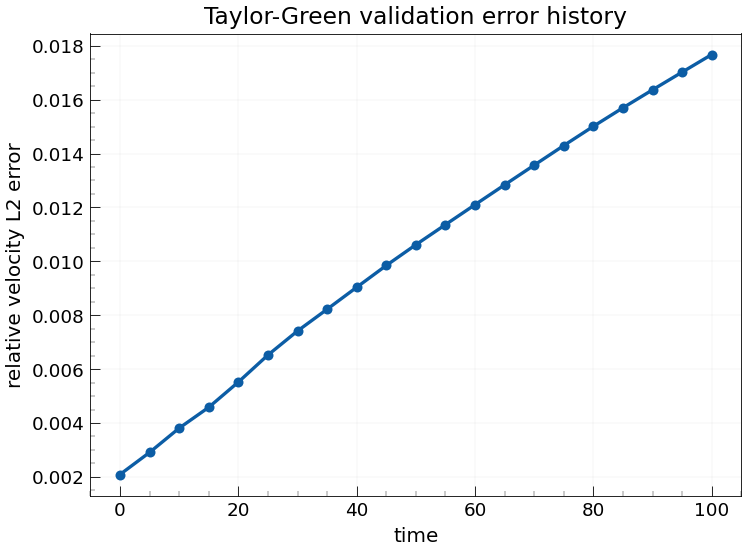

In [4]:
times = [r['time'] for r in records]
errors = [r['rel_l2'] for r in records]

fig, ax = plt.subplots()
ax.plot(times, errors, marker='o', linewidth=2)
ax.set_xlabel('time')
ax.set_ylabel('relative velocity L2 error')
ax.set_title('Taylor-Green validation error history')
plt.show()


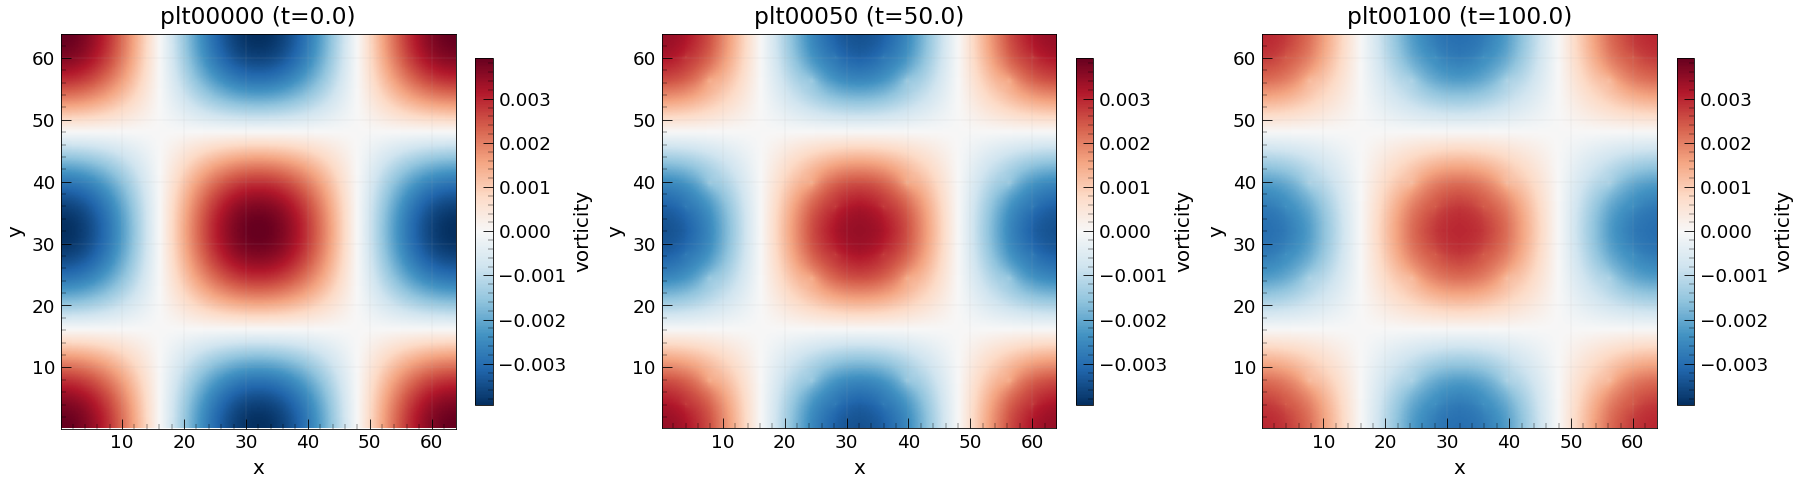

In [5]:
fig, axes = plt.subplots(1, len(snapshots), figsize=(5 * len(snapshots), 4), constrained_layout=True)
if len(snapshots) == 1:
    axes = [axes]

for ax, r in zip(axes, snapshots):
    im = ax.imshow(
        r['vor'].T,
        extent=[r['x'][0], r['x'][-1], r['y'][0], r['y'][-1]],
        cmap='RdBu_r',
        vmin=-vor_vmax,
        vmax=vor_vmax,
    )
    ax.set_title(f"{r['plotfile']} (t={r['time']:.1f})")
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    fig.colorbar(im, ax=ax, shrink=0.85, label='vorticity')

plt.show()


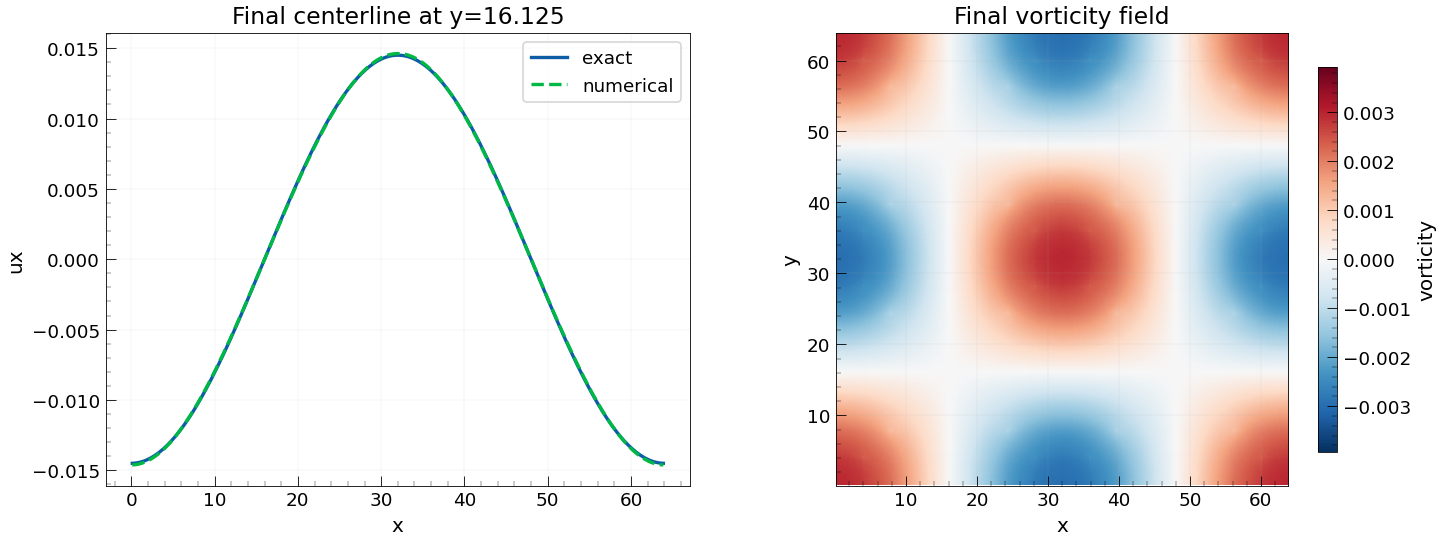

In [6]:
final = records[-1]
y_target = 0.25 * (final['y'][0] + final['y'][-1] + (final['y'][1] - final['y'][0]))
j = int(np.argmin(np.abs(final['y'] - y_target)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
axes[0].plot(final['x'], final['uex'][:, j], label='exact', linewidth=2)
axes[0].plot(final['x'], final['ux'][:, j], '--', label='numerical', linewidth=2)
axes[0].set_xlabel('x')
axes[0].set_ylabel('ux')
axes[0].set_title(f"Final centerline at y={final['y'][j]:.3f}")
axes[0].legend()

im = axes[1].imshow(
    final['vor'].T,
    extent=[final['x'][0], final['x'][-1], final['y'][0], final['y'][-1]],
    cmap='RdBu_r',
    vmin=-vor_vmax,
    vmax=vor_vmax,
)
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('Final vorticity field')
fig.colorbar(im, ax=axes[1], shrink=0.85, label='vorticity')

plt.show()
